In [14]:
import numpy as np

import math 
import matplotlib.pyplot as plt
# the last 2 libraries are just for the better understanding of algo.

In [17]:
x_train = np.array([
    [59],
    [30],
    [19],
    [27],
    [45]
])  # shape (n_samples, n_features)

x_raw= x_train

y_train = np.array([50000, 40000 , 20000, 37000, 45000])

y_raw = y_train

n_samples , n_features = x_train.shape

In [18]:
x_mean= np.mean(x_train)
x_std= np.std(x_train)

y_mean= np.mean(y_train)
y_std= np.std(y_train)

In [19]:
x_train= (x_train - x_mean)/ x_std

y_train=( y_train - y_mean)/y_std

In [20]:
x_train.shape

(5, 1)

<function matplotlib.pyplot.show(close=None, block=None)>

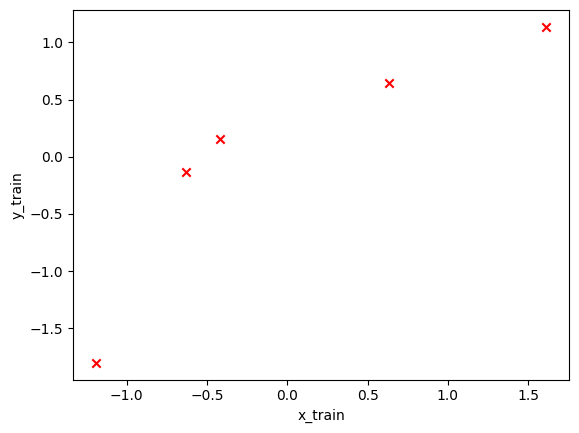

In [21]:
plt.scatter(x_train, y_train, marker='x', c='r')
plt.xlabel("x_train")
plt.ylabel("y_train")
plt.show

In [22]:
def compute_cost( x,y,w,b):

    m= x_train.shape[0]

    total_cost =0

    cost_sum=0

    for i in range(m):            # w and b are given by argument
        f_wb = w * x[i][0] +b    # accesing fist colums element by element
        loss= (f_wb - y[i])**2  
        cost_sum = cost_sum + loss

    total_cost = (1/2*m) * cost_sum  

    return total_cost    


In [23]:
initial_w = 2
initial_b = 1

cost= compute_cost(x_train, y_train , initial_w , initial_b)
print(type(cost))

print(f'Cost at initial weight and bias: {cost:.3f}')

<class 'numpy.float64'>
Cost at initial weight and bias: 30.888


In [24]:
def compute_gradient( x,y, w,b):
    
    m= x.shape[0]

    dj_dw = 0

    dj_db = 0

    for i in range(m):
        f_wb= w* x[i] + b
        dj_dw_i= ((f_wb - y[i])* x[i])        # This is the slope (gradient) of the loss function contributed by the data point at   x= x[i]
        dj_db_i= (f_wb - y[i])                # Each data point says how it wants the weight w to change based on its error and input value.

        dj_dw += dj_dw_i                    #Add all data points’ opinions to get the overall direction to move w.
        dj_db += dj_db_i

    dj_db = dj_dw /m                #Average ensures the update size is independent of dataset size and stable.

    dj_db= dj_db/ m

    return dj_dw, dj_db

In [25]:
test_w= 0
test_b =0

temp_dj_dw , temp_dj_db = compute_gradient( x_train , y_train , test_w ,test_b )

print( " Gradient at w=0 , b= 0 is :" , temp_dj_dw , temp_dj_db)

 Gradient at w=0 , b= 0 is : [-4.41119214] [-0.17644769]


In [26]:
# Compute and display cost and gradient with non-zero w
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: [-3.41119214] [-0.13644769]


In [28]:
def gradient_descent( x, y, w_in, b_in , compute_cost , compute_gradient, alpha , num_iters):

    m =len(x)
    
    J_history = []                   # these are just for visualization
    w_history = []
    w = w_in
    b = b_in

    for i in range (num_iters):

        dj_dw, dj_db = compute_gradient(x , y, w, b)



        w= w - alpha * dj_dw
        b= b - alpha * dj_db


        if i <100000 : 
            cost = compute_cost( x,y, w,b)
            J_history.append(cost)

        if i% math.ceil(num_iters /10) ==0: 
            w_history.append(w)
            print(f"Iteration {i: 4}: Cost: { float(J_history[-1]):8.2f}  ")
    
    return w, b, J_history , w_history 



In [29]:
initial_w=0
initial_b =0 

iteration=1500
alpha= 0.1

w,b,j_hist,w_hist = gradient_descent( x_train , y_train ,initial_w, initial_b , compute_cost, compute_gradient , alpha , iteration)

print( " w, b found by gradient Descent: ", w,b)


Iteration    0: Cost:     5.21  
Iteration  150: Cost:     2.79  
Iteration  300: Cost:     2.79  
Iteration  450: Cost:     2.79  
Iteration  600: Cost:     2.79  
Iteration  750: Cost:     2.79  
Iteration  900: Cost:     2.79  
Iteration  1050: Cost:     2.79  
Iteration  1200: Cost:     2.79  
Iteration  1350: Cost:     2.79  
 w, b found by gradient Descent:  [0.88223843] [0.03528954]


C:\Users\shiva\AppData\Local\Temp\ipykernel_32688\798153477.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Iteration {i: 4}: Cost: { float(J_history[-1]):8.2f}  ")


In [30]:
m = x_train.shape[0]
print(m)
predicted = np.zeros(m)
y_norm_pred= np.zeros(m)

for i in range(m):
    y_norm_pred[i] = w * x_train[i] + b
    predicted[i] = y_norm_pred[i] * y_std + y_mean

5


C:\Users\shiva\AppData\Local\Temp\ipykernel_32688\2318924073.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_norm_pred[i] = w * x_train[i] + b


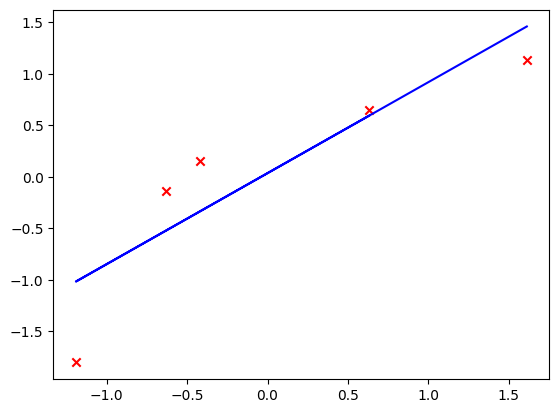

In [97]:
# plotting
plt.plot(x_train, y_norm_pred, c = "b")

# Create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r') 


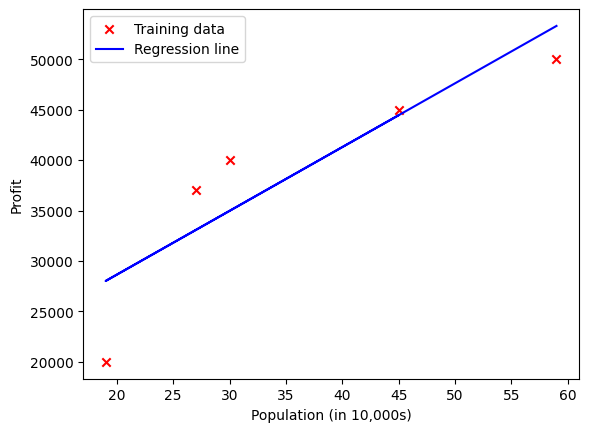

In [ ]:
# Flatten for plotting
x_plot = x_raw.flatten()

x_norm = (x_plot - x_mean) / x_std

# Predict normalized y
y_norm_pred = w * x_norm + b

# Convert prediction back to original y scale
y_pred = y_norm_pred * y_std + y_mean

# Plot
plt.scatter(x_raw, y_raw, marker='x', c='r', label="Training data")
plt.plot(x_plot, y_pred, c='b', label="Regression line")

plt.xlabel("Population (in 10,000s)")
plt.ylabel("Profit")
plt.legend()
plt.show()

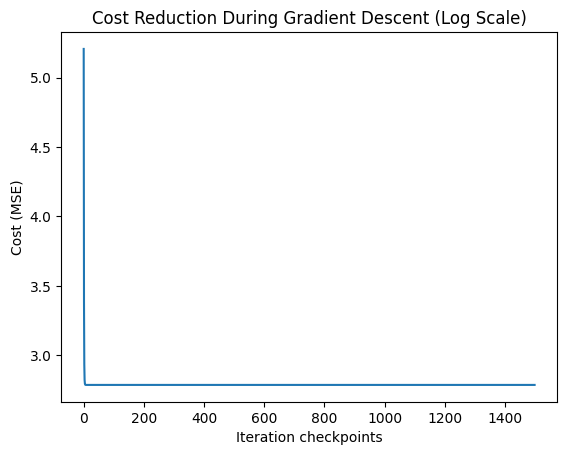

In [34]:
plt.plot(j_hist)

plt.xlabel("Iteration checkpoints")
plt.ylabel("Cost (MSE)")
plt.title("Cost Reduction During Gradient Descent (Log Scale)")
plt.show()



- Cost (MSE) falls from ~5.2 → ~2.8 in the first few iterations.
- Cost stays almost constant for the remaining ~1500 iterations.
- Curve is smooth, not zig-zag or diverging.
- Learning rate is not too high

* raw x  → normalize x  → model → normalized y  → de-normalize y → real prediction

In [113]:
x1 = (35 - x_mean) / x_std
x2 = (70 - x_mean) / x_std

y1_norm = w * x1 + b
y2_norm = w * x2 + b

y1 = y1_norm * y_std + y_mean
y2 = y2_norm * y_std + y_mean

y1= y1.item()
y2= y2.item()

In [114]:
print(f"For Age = 35, predicted profit = ${y1:.2f}")
print(f"For Age = 70, predicted profit = ${y2:.2f}")

For Age = 35, predicted profit = $38128.41
For Age = 70, predicted profit = $60244.55


---


## Multiple linear Regression

In [8]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_hat = X @ w + b          # (m,1)
    error = y_hat - y
    cost = (1/(2*m)) * np.sum(error**2)
    return cost


In [9]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    y_hat = X @ w + b
    error = y_hat - y

    dj_dw = (1/m) * (X.T @ error)   # (n,1)
    dj_db = (1/m) * np.sum(error)   # scalar

    return dj_dw, dj_db


In [10]:
def gradient_descent(X, y, w, b, alpha, iterations):
    J_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i % (iterations // 10) == 0:
            cost = compute_cost(X, y, w, b)
            J_history.append(cost)
            print(f"Iteration {i}: Cost {cost:.4f}")

    return w, b, J_history


In [11]:
# X shape: (m, n)
X = np.array([
    [2100, 3],
    [1600, 2],
    [2400, 4],
    [1400, 2]
])

y = np.array([[400000], [330000], [369000], [280000]])

# Normalize X (IMPORTANT)
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# Initialize
w = np.zeros((X.shape[1], 1))  # (n,1)
b = 0
alpha = 0.1
iterations = 1000

w, b, _ = gradient_descent(X_norm, y, w, b, alpha, iterations)


Iteration 0: Cost 48924021506.8137
Iteration 100: Cost 235182639.2582
Iteration 200: Cost 144968825.4975
Iteration 300: Cost 94911565.3470
Iteration 400: Cost 67136104.6657
Iteration 500: Cost 51724230.0697
Iteration 600: Cost 43172585.1019
Iteration 700: Cost 38427501.6145
Iteration 800: Cost 35794579.2484
Iteration 900: Cost 34333639.6877


In [12]:
x_new = np.array([[2000, 3]])
x_new_norm = (x_new - X_mean) / X_std

y_pred = x_new_norm @ w + b
print(float(y_pred))


357067.1862090671


C:\Users\shiva\AppData\Local\Temp\ipykernel_32688\2874207129.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(y_pred))


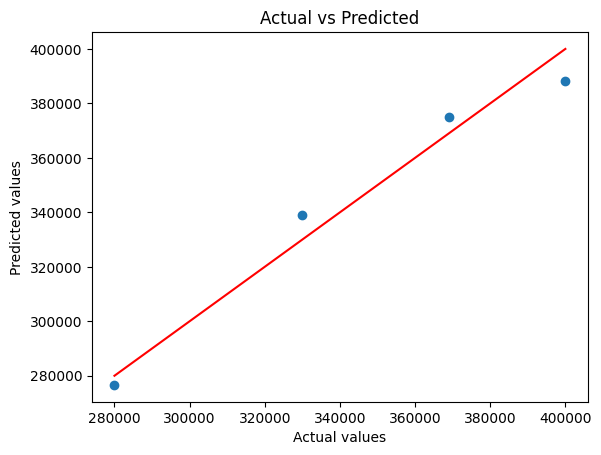

In [15]:
y_pred = X_norm @ w + b

plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], c='r')  # perfect fit line
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")
plt.show()
